<div align="center">
    <font color="0F5298" size="7">
        Deep Learning <br>
    </font>
    <font color="2565AE" size="5">
        CE Department <br>
        Spring 2024 - Prof. Soleymani Baghshah <br>
    </font>
    <font color="3C99D" size="5">
        HW2 Practical <br>
    </font>
    <font color="696880" size="5">
        30 Points
    </font>
</div>


In this notebook, we aim to perform **classification** on images from the **CIFAR10** dataset using CNN networks. First, we load the dataset and apply the necessary transformations for normalization and augmentation. After that, we visualize some samples. Once we familiarize ourselves with the dataset, we proceed to design the desired convolutional network, which is explained in the relevant section. After designing the model, we move on to training and evaluating it. At the end of the first section, we analyze the feature space from different perspectives. First, using the KNN method, we examine the closest samples to each other in the feature space. Then, we cluster the data and finally visualize the outputs of the intermediate layers of the model.

In the second part of the notebook, we perform a simple transfer learning task on the trained model from the first section but using a new dataset, **CIFAR100**. To do this, we modify the final layer of the network and retrain it. Further details are provided in the relevant section. Finally, we evaluate the model’s accuracy on the new task and analyze the extracted features and how well the model generalizes. After designing and training the model, we will further analyze the extracted feature space. Finally, we will evaluate the generalization ability of the model and its extracted features on a new dataset,

# CIFAR10 Classification

## Import Libraries

Import needed libraries

In [5]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F
import tqdm
from time import time
import random
from sklearn.manifold import TSNE
import numpy as np
from random import sample
import math
import torch.optim as optim
import seaborn as sns

## Device

Set device to work with (GPU or CPU)

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Transforms & Dataset & Dataloader

Here, you should download and load the dataset with the desire transforms. After that, you should split train dataset to train and validation sets. Finally, define the dataloaders for `train`, `validation` and `test`

In [3]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [6]:

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)


train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# -----------------------------
# TODO: Load Test Data
# -----------------------------
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

# -----------------------------
# TODO: Define Data Loaders
# -----------------------------
batch_size = 128

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

dataloaders = {
    "train": train_loader,
    "val": val_loader,
    "test": test_loader
}

dataset_sizes = {
    "train": len(train_subset),
    "val": len(val_subset),
    "test": len(test_dataset)
}

print("Dataset sizes:", dataset_sizes)


Dataset sizes: {'train': 40000, 'val': 10000, 'test': 10000}


## Visualization

Visualize 5 random images from each class in different columns

- **Hint**:  You can use `plt.subplots` for visualization

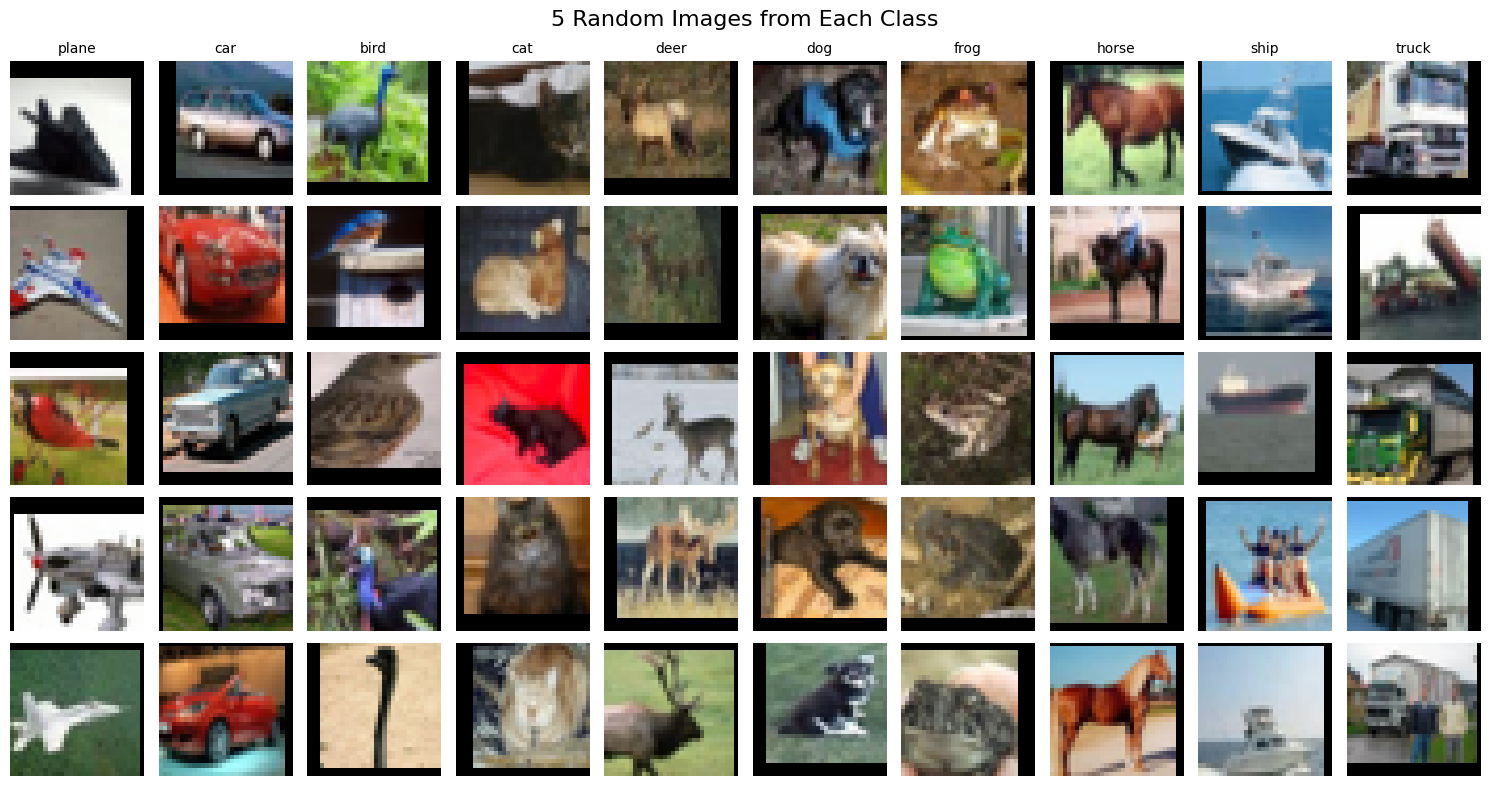

In [8]:
# Function to unnormalize images for plotting
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = std * img + mean  # unnormalize
    img = np.clip(img, 0, 1)
    return img

# ------------------------------------
# TODO: Find 5 Images from Each Class
# ------------------------------------
num_classes = len(classes)
samples_per_class = 5

# Create dictionary of lists for each class
class_images = {cls: [] for cls in classes}

# Iterate dataset until we have 5 images for each class
for img, label in train_dataset:
    cls_name = classes[label]
    if len(class_images[cls_name]) < samples_per_class:
        class_images[cls_name].append(img)
    if all(len(v) == samples_per_class for v in class_images.values()):
        break

# ------------------------
# Plot Images
# ------------------------
fig, axes = plt.subplots(nrows=samples_per_class, ncols=num_classes,
                         figsize=(15, 8))
fig.suptitle("5 Random Images from Each Class", fontsize=16)

for col, cls in enumerate(classes):
    for row in range(samples_per_class):
        axes[row, col].imshow(imshow(class_images[cls][row]))
        axes[row, col].axis("off")
        if row == 0:  # put class name on top row
            axes[row, col].set_title(cls, fontsize=10)

plt.tight_layout()
plt.show()


## Model

Define your model here from scratch (You are not allowed to use the existing models in pytorch)

**NOTICE:** The model that you will have defined outputs a vector containing 10 numbers (for each class). Define a "feature space" that is a vector of size *N* (where *N > 10*) right before the last layer (You can then have a last layer like `nn.Linear(N, 10)`). See the image below to get a better understanding. We will use this later (we want to access the feature space of a sample when the sample is given to the model). The model tries to learn a representation of the samples in this feature space and we will see how good it could do this in later sections.

![Feature Space In Neural Network](https://i.postimg.cc/28Qjcn9D/feature-space-vis.png)

- **Hint I**: Our goal is to get accuracy above *90%* on testset. Our suggestion is to implement ResNet (ResNet18 could be a viable choice)
  - You can learn the network's structure and implementation online (Youtube, ...) and then implmenet it yourself and make changes to enhance it's performance on our task **(YOU SHOULD NOT COPY THE CODE!!! OTHERWISE, YOU'LL BE PENALIZED!!!)**

- **Hint II**: When defining your model, pay attension to the **NOTICE** part in the above. It's also better to read the "Exploring the feature space" section beforehand.  

In [27]:
def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1, bias=False):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=dilation, bias=bias, dilation=dilation, groups=groups)

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, downsample=None, norm_layer=None,
                 dropout_rate=0.0, se_ratio=0.0):
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d

        # First convolution
        self.conv1 = conv3x3(in_planes, planes, stride)
        self.bn1 = norm_layer(planes)

        # Second convolution
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)

        # Activation
        self.relu = nn.ReLU(inplace=True)

        # Squeeze-and-Excitation (optional)
        self.se_ratio = se_ratio
        if se_ratio > 0:
            self.se = SqueezeExcitation(planes, reduction_ratio=se_ratio)

        # Dropout (optional)
        self.dropout = nn.Dropout2d(dropout_rate) if dropout_rate > 0 else None

        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        if self.dropout is not None:
            out = self.dropout(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Squeeze-and-Excitation
        if hasattr(self, 'se'):
            out = self.se(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

class SqueezeExcitation(nn.Module):
    """Squeeze-and-Excitation block for channel attention"""
    def __init__(self, channels, reduction_ratio=16):
        super().__init__()
        reduced_channels = max(1, channels // reduction_ratio)
        self.fc1 = nn.Conv2d(channels, reduced_channels, kernel_size=1)
        self.fc2 = nn.Conv2d(reduced_channels, channels, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Global average pooling
        se = F.adaptive_avg_pool2d(x, 1)
        se = self.fc1(se)
        se = self.relu(se)
        se = self.fc2(se)
        se = self.sigmoid(se)
        return x * se

class ResNetCustom(nn.Module):
    def __init__(self, block=BasicBlock, layers=(2,2,2,2), num_classes=10, feature_dim=256,
                 zero_init_residual=True, norm_layer=None, dropout_rate=0.0, se_ratio=0.0,
                 stem_kernel=3, width_multiplier=1.0):
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer

        # Width multiplier for channel scaling
        self.width_multiplier = width_multiplier
        base_width = 64

        self.inplanes = int(base_width * width_multiplier)

        # Improved stem with optional larger kernel
        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=stem_kernel, stride=1,
                              padding=stem_kernel//2, bias=False)
        self.bn1 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)

        # Optional stem dropout
        self.stem_dropout = nn.Dropout2d(dropout_rate * 0.5) if dropout_rate > 0 else None

        # Stages with progressive channel scaling
        self.layer1 = self._make_layer(block, int(64 * width_multiplier), layers[0],
                                      stride=1, dropout_rate=dropout_rate, se_ratio=se_ratio)
        self.layer2 = self._make_layer(block, int(128 * width_multiplier), layers[1],
                                      stride=2, dropout_rate=dropout_rate, se_ratio=se_ratio)
        self.layer3 = self._make_layer(block, int(256 * width_multiplier), layers[2],
                                      stride=2, dropout_rate=dropout_rate, se_ratio=se_ratio)
        self.layer4 = self._make_layer(block, int(512 * width_multiplier), layers[3],
                                      stride=2, dropout_rate=dropout_rate, se_ratio=se_ratio)

        # Enhanced feature projection
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Feature projection with batch norm and dropout
        final_channels = int(512 * width_multiplier) * block.expansion
        self.feature_bn = norm_layer(final_channels)
        self.feature_dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None

        self.feature_proj = nn.Sequential(
            nn.Linear(final_channels, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate) if dropout_rate > 0 else nn.Identity()
        )

        # Classifier with better initialization
        self.fc = nn.Linear(feature_dim, num_classes)

        # Improved initialization
        self._initialize_weights(zero_init_residual)

    def _make_layer(self, block, planes, blocks, stride=1, dropout_rate=0.0, se_ratio=0.0):
        norm_layer = self._norm_layer
        downsample = None

        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                         kernel_size=1, stride=stride, bias=False),
                norm_layer(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample, norm_layer,
                           dropout_rate, se_ratio))
        self.inplanes = planes * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes, norm_layer=norm_layer,
                              dropout_rate=dropout_rate, se_ratio=se_ratio))

        return nn.Sequential(*layers)

    def _initialize_weights(self, zero_init_residual):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def forward(self, x, return_feature=False):
        # Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        if self.stem_dropout is not None:
            x = self.stem_dropout(x)

        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Global pooling with feature enhancement
        x = self.avgpool(x)
        x = self.feature_bn(x)  # Apply BN before flattening
        x = torch.flatten(x, 1)

        if self.feature_dropout is not None:
            x = self.feature_dropout(x)

        # Feature projection
        features = self.feature_proj(x)

        # Final classifier
        logits = self.fc(features)

        if return_feature:
            return logits, features
        return logits


## Train

### Model instantiation

Create an instance of your model and move it to `device`

In [32]:
model = ResNetCustom(
        block=BasicBlock,
        layers=[3, 3, 3, 3],  # ResNet-34 style
        num_classes=10,
        feature_dim=512,  # Larger feature space
        zero_init_residual=True,
        dropout_rate=0.1,  # Mild regularization
        se_ratio=16,  # Squeeze-and-Excitation
        width_multiplier=1.0,  # Standard width
        stem_kernel=3
    ).to(device)

### Criterion & Optimizater

Define `criterion` and `optimizer` (Or `scheduler`)

In [33]:

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR

optimizer = AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=50)

# Enhanced criterion with label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


### Train loop

Train your model

Tasks:
- [ ] Things that are needed to be printed in each epoch:
  - Number of epoch
  - Train loss
  - Train accuracy
  - Validation loss
  - Validation accuracy
- [ ] save train/validation loss and accuracy (of each epoch) in an array for later usage

In [35]:


import time  # Add this at the top

# Enhanced training function with timing
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes,
                num_epochs=50, early_stopping_patience=10, grad_clip=None):
    best_acc = 0.0
    best_epoch = 0
    patience_counter = 0

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "learning_rate": [],
        "epoch_time": []  # store time per epoch
    }

    total_start_time = time.time()  # Track total training time

    for epoch in range(num_epochs):
        epoch_start_time = time.time()  # Start time for this epoch

        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()

                        # Gradient clipping
                        if grad_clip is not None:
                            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train' and scheduler is not None:
                if isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
                    scheduler.step()
                current_lr = scheduler.get_last_lr()[0] if hasattr(scheduler, 'get_last_lr') else optimizer.param_groups[0]['lr']
                history["learning_rate"].append(current_lr)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Save stats
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())

            # Early stopping and model checkpointing
            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_epoch = epoch
                    best_wts = model.state_dict().copy()
                    patience_counter = 0

                    # Save best model checkpoint
                    torch.save({
                        'epoch': epoch,
                        'model_state_dict': best_wts,
                        'optimizer_state_dict': optimizer.state_dict(),
                        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                        'best_acc': best_acc,
                    }, 'best_model.pth')
                else:
                    patience_counter += 1

        # Step scheduler for non-OneCycleLR schedulers
        if scheduler is not None and not isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(history["val_loss"][-1])
            else:
                scheduler.step()

        # Epoch timing
        epoch_end_time = time.time()
        epoch_duration = epoch_end_time - epoch_start_time
        history["epoch_time"].append(epoch_duration)
        print(f"Epoch time: {epoch_duration:.2f} sec")

        # Early stopping check
        if patience_counter >= early_stopping_patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    total_end_time = time.time()
    total_duration = total_end_time - total_start_time
    print(f"\nBest val Acc: {best_acc:.4f} at epoch {best_epoch+1}")
    print(f"Total training time: {total_duration:.2f} sec")

    model.load_state_dict(best_wts)
    return model, history



model, history = train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, num_epochs=50)



Epoch 1/50
--------------------
train Loss: 1.4672 Acc: 0.5536
val Loss: 1.4285 Acc: 0.5799
Epoch time: 57.12 sec

Epoch 2/50
--------------------
train Loss: 1.2900 Acc: 0.6412
val Loss: 1.2388 Acc: 0.6741
Epoch time: 56.29 sec

Epoch 3/50
--------------------
train Loss: 1.1872 Acc: 0.6927
val Loss: 1.1546 Acc: 0.7039
Epoch time: 56.03 sec

Epoch 4/50
--------------------
train Loss: 1.1033 Acc: 0.7302
val Loss: 1.0778 Acc: 0.7479
Epoch time: 56.54 sec

Epoch 5/50
--------------------
train Loss: 1.0342 Acc: 0.7653
val Loss: 1.0334 Acc: 0.7676
Epoch time: 55.97 sec

Epoch 6/50
--------------------
train Loss: 0.9815 Acc: 0.7888
val Loss: 0.9843 Acc: 0.7860
Epoch time: 56.65 sec

Epoch 7/50
--------------------
train Loss: 0.9433 Acc: 0.8046
val Loss: 0.9301 Acc: 0.8106
Epoch time: 55.61 sec

Epoch 8/50
--------------------
train Loss: 0.9082 Acc: 0.8221
val Loss: 0.8968 Acc: 0.8285
Epoch time: 56.37 sec

Epoch 9/50
--------------------
train Loss: 0.8747 Acc: 0.8373
val Loss: 0.8893

### Save Model

Since changes need to be made to the model later on, it is advisable to save your model to avoid having to retrain it in case of any issues.

In [36]:
# TODO: Save Model
save_path = "resnet_cifar10.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")


Model saved to resnet_cifar10.pth


### Visualize Loss and Accuracy plot

Using the arrays that you have (from task 2 in the above section), visualize two plots: Accuracy plot (train and validation together) and Loss plot (train and validation together)

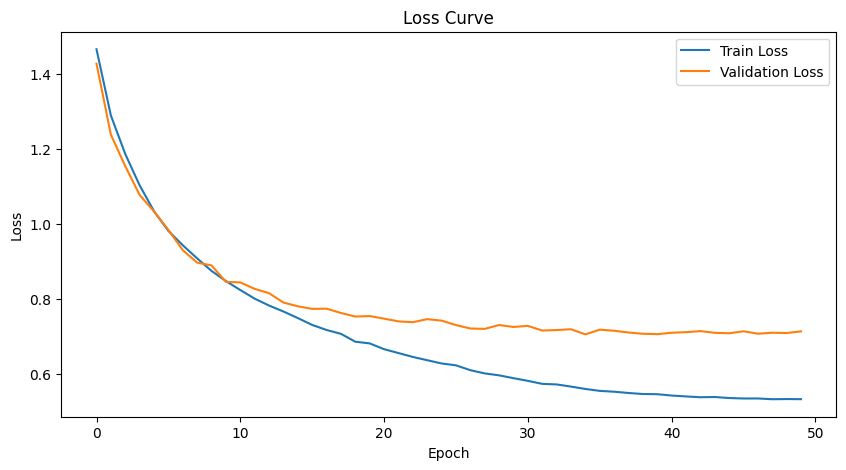

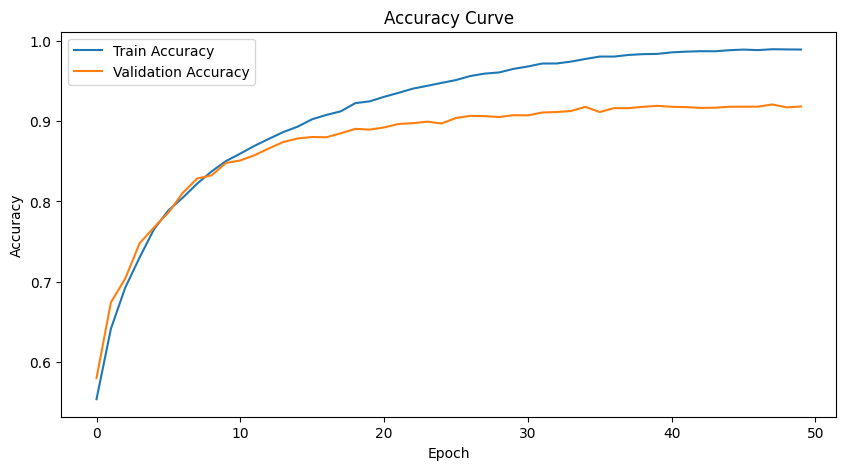

In [37]:

# TODO: Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

# TODO: Plot Accuracy
plt.figure(figsize=(10,5))
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()


## Evaluation

Test your trained model (using the Test Dataloader that you have). Our goal is to reach an accuracy above `90%`

In [38]:
def evaluate_model(model, dataloader, device):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    return acc

# Run evaluation
test_acc = evaluate_model(model, dataloaders['test'], device)


Test Accuracy: 91.51%


## Visualize incorrectly predicted samples from testset

Visualize *24* random images from testset that are incorrectly predicted by the model. Note that if you used normalization in the transform function for loading the data, you will need to unnormalize the images before displaying them.

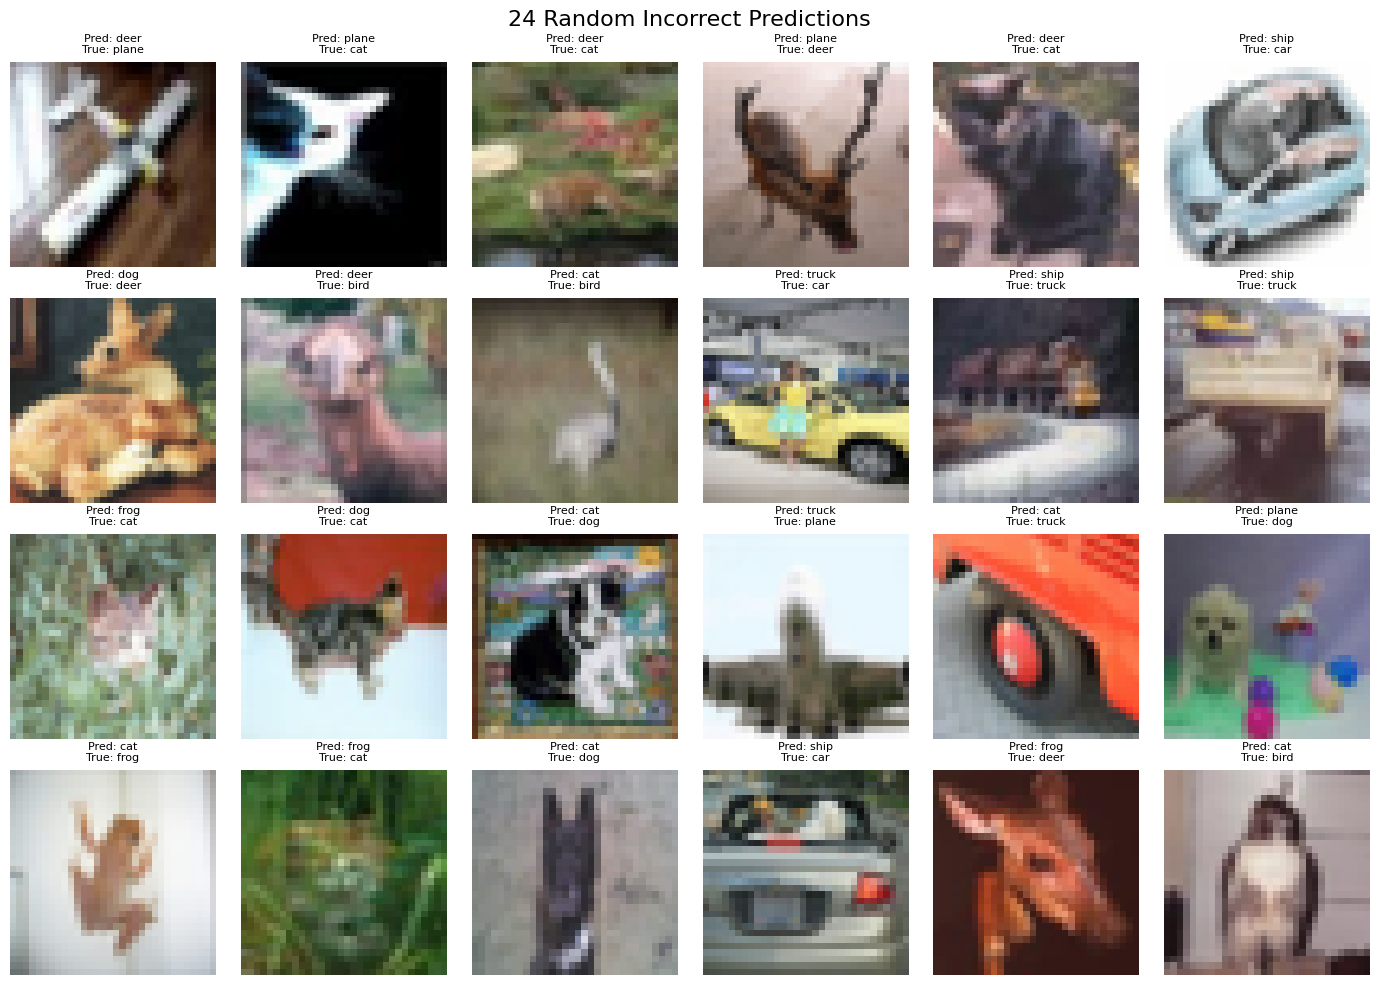

In [41]:
# Collect incorrect predictions
def get_incorrect_samples(model, dataloader, device, max_samples=500):
    model.eval()
    wrong_images, wrong_preds, wrong_labels = [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            mismatches = preds != labels
            for img, pred, label, wrong in zip(inputs, preds, labels, mismatches):
                if wrong:
                    wrong_images.append(img)
                    wrong_preds.append(pred.item())
                    wrong_labels.append(label.item())

            if len(wrong_images) >= max_samples:  # avoid storing too many
                break

    return wrong_images, wrong_preds, wrong_labels

# Get misclassified samples
wrong_images, wrong_preds, wrong_labels = get_incorrect_samples(model, dataloaders['test'], device)

# Pick 24 random wrong samples
indices = random.sample(range(len(wrong_images)), 24)

# Plot
fig, axes = plt.subplots(4, 6, figsize=(14, 10))
fig.suptitle("24 Random Incorrect Predictions", fontsize=16)

for ax, idx in zip(axes.flat, indices):
    img = imshow(wrong_images[idx].cpu())
    ax.imshow(img)
    ax.set_title(f"Pred: {classes[wrong_preds[idx]]}\nTrue: {classes[wrong_labels[idx]]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


## Exploring the feature space

### Calculate the feature space for all training samples

You have trained and evaluated your model. Now, for each sample in the trainset, calculate it's "feature space" discussed in the model section. The result of this section should be a tensor of size `(40000, N)` saved in a variable (for later usage)

- **Hint 1:** define a tensor with dimension `(40000, N)` where *40000* is the size of the trainset and *N* is the dimension of the feature space

- **Hint 2:** Pay attension to the `shuffle` attribute of your train dataloader (If needed)

In [55]:
# TODO: Find Features and Put Them in One Dimensional List
def extract_features(model, dataloader, device, feature_type='projected'):
    """
    Extract features from different stages of the ResNetCustom model.

    Args:
        model: Your trained ResNetCustom model
        dataloader: DataLoader for the training set
        device: Device to run the computation on
        feature_type: Type of features to extract ('pooled', 'projected')
                     - 'pooled': After global average pooling, before projection
                     - 'projected': After feature projection (default)

    Returns:
        features_tensor: Tensor containing all features
        labels_tensor: Tensor containing all labels
    """
    model.eval()

    features_list = []
    labels_list = []

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)

            # Forward pass until the desired feature extraction point
            x = model.conv1(data)
            x = model.bn1(x)
            x = model.relu(x)

            if model.stem_dropout is not None:
                x = model.stem_dropout(x)

            # Residual layers
            x = model.layer1(x)
            x = model.layer2(x)
            x = model.layer3(x)
            x = model.layer4(x)

            # Global pooling
            x = model.avgpool(x)
            x = model.feature_bn(x)
            x = torch.flatten(x, 1)

            if model.feature_dropout is not None:
                x = model.feature_dropout(x)

            if feature_type == 'pooled':
                # Features after pooling but before projection
                features = x
            else:  # 'projected'
                # Features after projection (default)
                features = model.feature_proj(x)

            features_list.append(features.cpu())
            labels_list.append(target.cpu())

    features_tensor = torch.cat(features_list, dim=0)
    labels_tensor = torch.cat(labels_list, dim=0)

    return features_tensor, labels_tensor

# Make sure your train_loader has shuffle=False to maintain sample order
train_loader = DataLoader(
    train_subset,
    batch_size=128,
    shuffle=False,  # Important: keep shuffle=False to maintain order
    num_workers=4
)

# Extract features
train_features, train_labels = extract_features(model, train_loader, device)

print(f"Feature tensor shape: {train_features.shape}")  # Should be (40000, 512)
print(f"Labels tensor shape: {train_labels.shape}")    # Should be (40000,)
print(f"Feature dimension: {train_features.shape[1]}") # Should be 512

Feature tensor shape: torch.Size([40000, 512])
Labels tensor shape: torch.Size([40000])
Feature dimension: 512


### K Nearest Neighbor in feature space

You already have calculated the feature spaces for trainset ($S$) in the previous section

1. Get 5 random samples from testset which are correctly predicted by the model.
2. for each sample, calculate it's "feature space" ($X$)
3. for each sample, calculate it's *5* nearest neighbors in "feature space" in the trainset (by comparing $X$ to each row in $S$) and visualize them

**Note:** Your visualization should be something like the below picture

**Hint:** To find the nearest neighbors in the feature space, you can use any library of your choice.

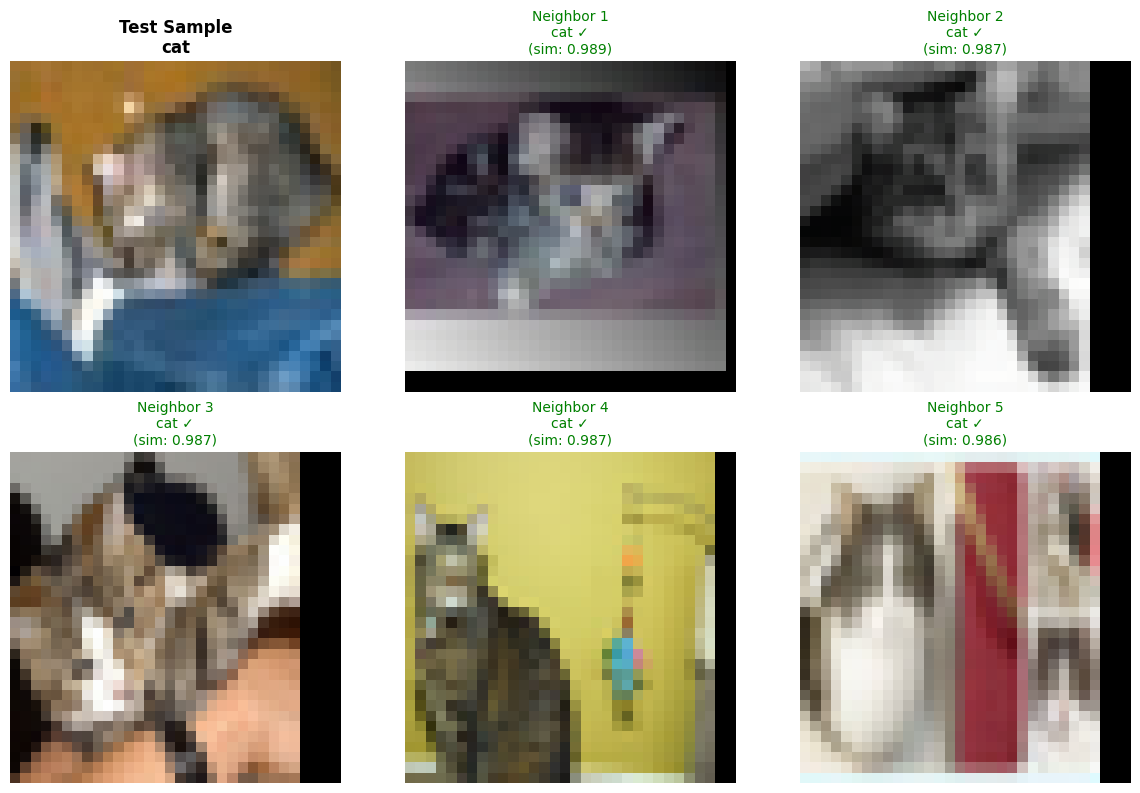

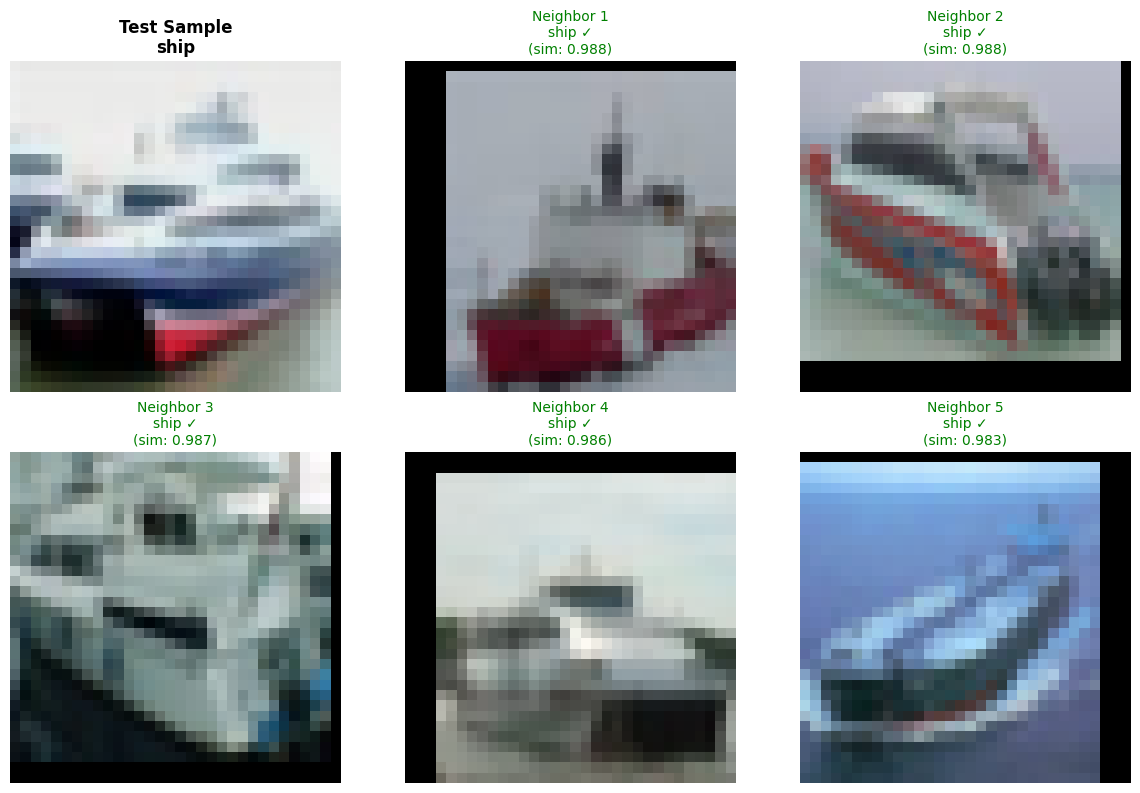

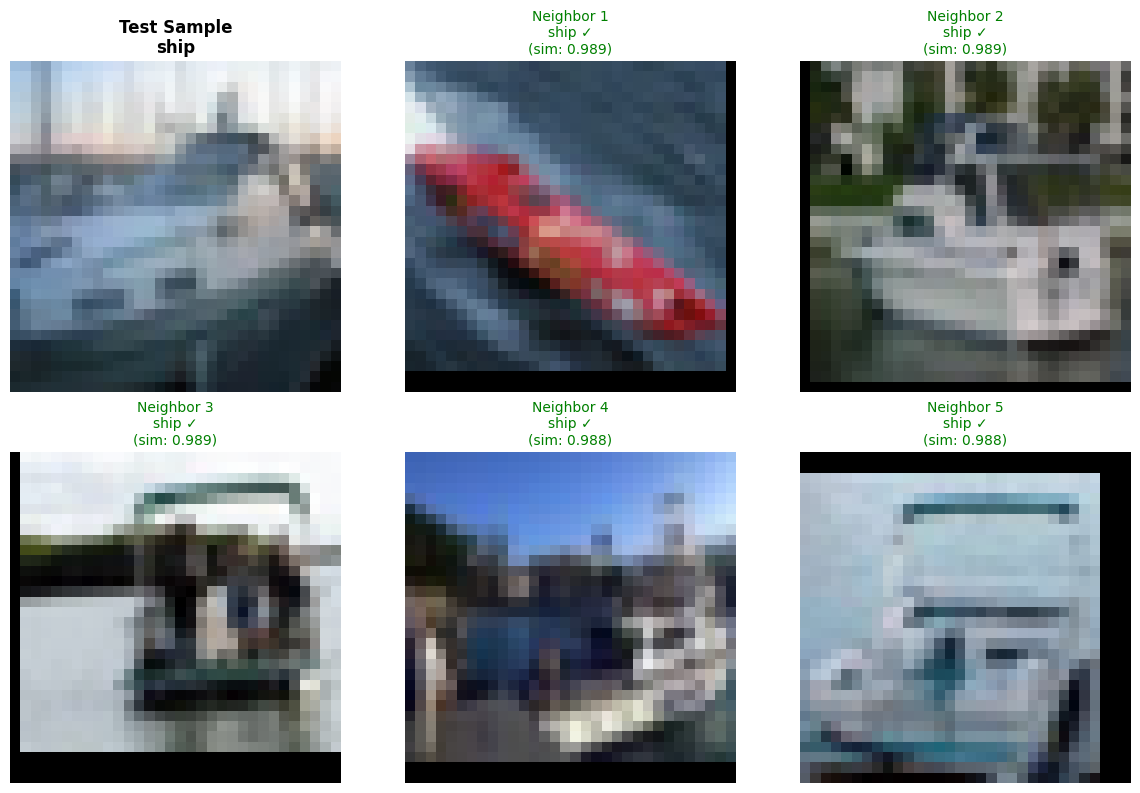

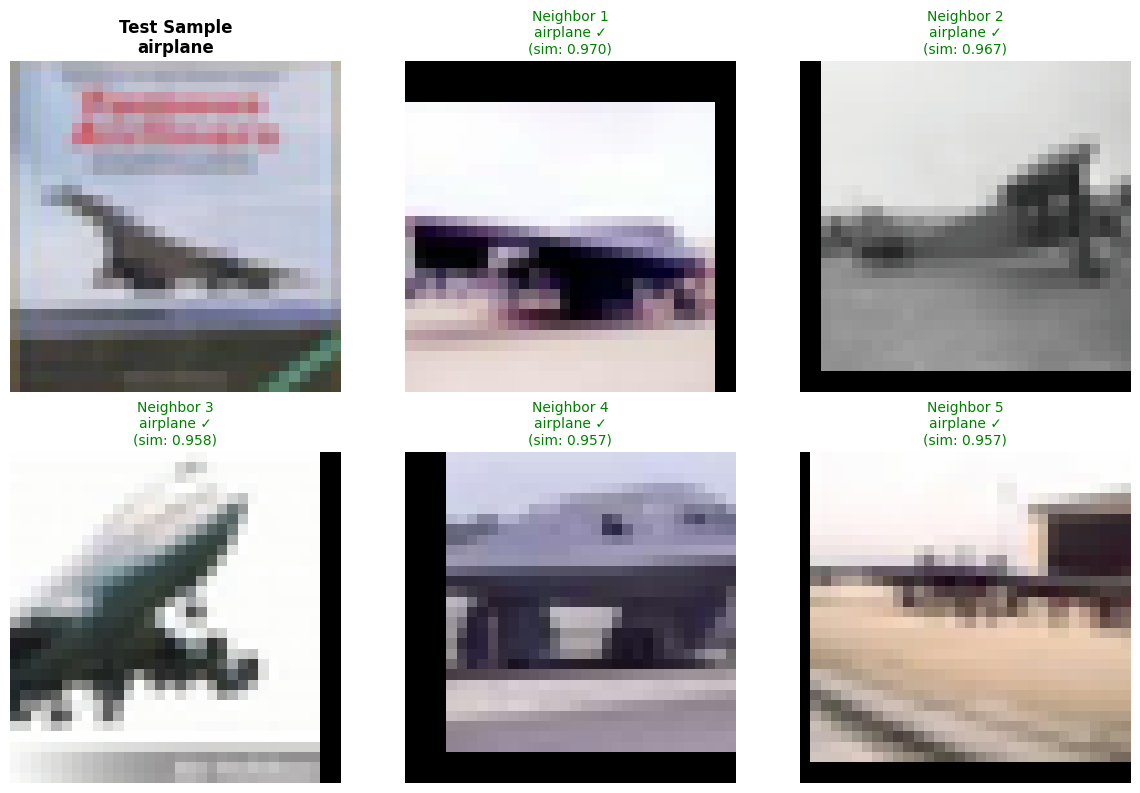

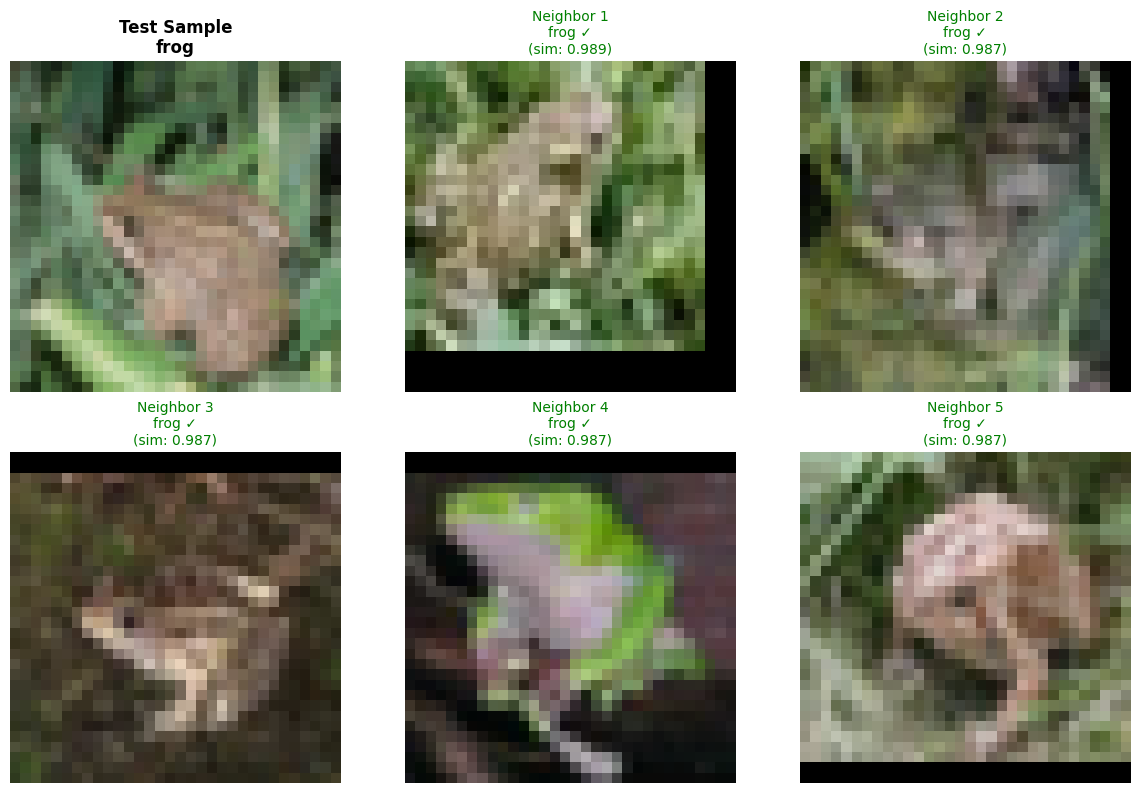

In [60]:
# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

def get_correct_predictions(model, test_loader, device, num_samples=5):
    """Get correctly predicted test samples and their features."""
    model.eval()
    correct_samples = []
    correct_features = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs, features = model(data, return_feature=True)
            preds = outputs.argmax(dim=1)

            correct_mask = (preds == target)
            correct_indices = correct_mask.nonzero(as_tuple=True)[0]

            for idx in correct_indices:
                if len(correct_samples) < num_samples:
                    correct_samples.append({
                        'image': data[idx].cpu(),
                        'true_label': target[idx].cpu(),
                        'pred_label': preds[idx].cpu(),
                        'feature': features[idx].cpu()
                    })
                    correct_features.append(features[idx].cpu())

            if len(correct_samples) >= num_samples:
                break

    return correct_samples[:num_samples]

def find_k_neighbors(test_feature, train_features, k=5):
    """Find k nearest neighbors using cosine similarity."""
    # Normalize features
    test_norm = test_feature / test_feature.norm()
    train_norm = train_features / train_features.norm(dim=1, keepdim=True)

    # Compute cosine similarities
    similarities = torch.mm(test_norm.unsqueeze(0), train_norm.T).squeeze(0)

    # Get top k neighbors
    top_similarities, top_indices = torch.topk(similarities, k=k)

    return top_indices, top_similarities


def visualize_sample_neighbors(test_sample, neighbor_indices, neighbor_similarities, train_features, train_labels, trainset):
    """Visualize a test sample and its k nearest neighbors."""
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()

    # Plot test sample
    test_img = imshow(test_sample['image'])
    axes[0].imshow(test_img)
    axes[0].set_title(f'Test Sample\n{class_names[test_sample["true_label"]]}',
                     fontweight='bold', fontsize=12)
    axes[0].axis('off')

    # Plot nearest neighbors
    for i, (idx, sim) in enumerate(zip(neighbor_indices, neighbor_similarities)):
        neighbor_img, neighbor_label = trainset[idx]
        neighbor_img = imshow(neighbor_img)

        axes[i+1].imshow(neighbor_img)
        label_match = "✓" if neighbor_label == test_sample['true_label'] else "✗"
        axes[i+1].set_title(f'Neighbor {i+1}\n{class_names[neighbor_label]} {label_match}\n(sim: {sim:.3f})',
                           fontsize=10, color='green' if label_match == "✓" else 'red')
        axes[i+1].axis('off')

    # Hide unused subplot
    for i in range(len(neighbor_indices) + 1, 6):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Main execution
correct_samples = get_correct_predictions(model, test_loader, device, num_samples=5)

for i, sample in enumerate(correct_samples):

    # Find nearest neighbors in precomputed feature space
    neighbor_indices, neighbor_similarities = find_k_neighbors(
        sample['feature'],
        train_features
    )

    # Visualize
    visualize_sample_neighbors(
        sample,
        neighbor_indices,
        neighbor_similarities,
        train_features,
        train_labels,
        train_subset
    )



### TSNE

1. Sample $M$ ($2000$ would be enought) random samples from the trainset feature space (calculated in the above sections)
2. Now you a vector of size `(M, N)` where $N$ is the dimension of the feature space
3. Using TSNE reduce $N$ to $2$ (Now you have a vector of size `(M, 2)`)
4. Print the shape of the output

**Hint:** You can use `sklearn.manifold.TSNE`

In [64]:
from sklearn.manifold import TSNE


# Compact implementation
M = 2000
random_state = 42

# Step 1: Sample M random points from feature space
np.random.seed(random_state)
indices = np.random.choice(len(train_features), M, replace=False)
sampled_features = train_features[indices].numpy()
sampled_labels = train_labels[indices].numpy()

print(f"Sampled features shape: {sampled_features.shape}")  # (2000, 512)

# Step 2: Apply TSNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=random_state, perplexity=30)
tsne_results = tsne.fit_transform(sampled_features)

# Step 3: Print the output shape
print(f"TSNE output shape: {tsne_results.shape}")  # (2000, 2)



Sampled features shape: (2000, 512)
TSNE output shape: (2000, 2)


Visualize the points in a 2D plane (Set color of each point based on it's class)

**Notice:** Your visualization should be something like the below image

**Hint:** Use `plt.scatter(x, y, c=labels)`

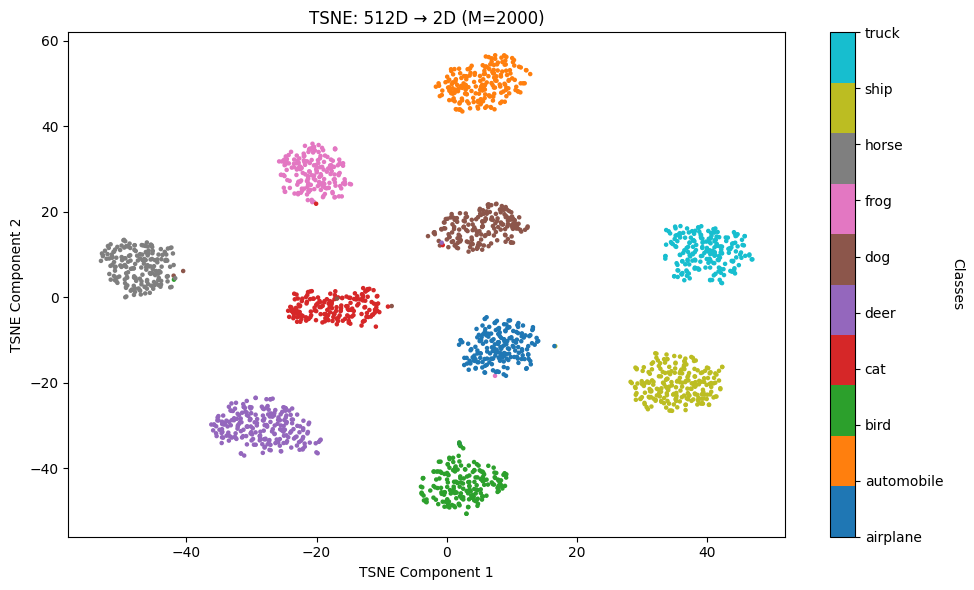

In [65]:
# Visualization with class names
plt.figure(figsize=(10, 6))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1],
           c=sampled_labels, cmap='tab10', alpha=1, s=5)

# Add colorbar with class names
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_ticklabels(class_names)
cbar.set_label('Classes', rotation=270, labelpad=15)

plt.title(f'TSNE: {train_features.shape[1]}D → 2D (M={M})')
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.tight_layout()
plt.show()

### Feature Map


In this part, we are going to visualize the output of one of the convolutional layers to see what features they focus on.

First, let's select a random image from dataset.

In [89]:
# Select a random image
idx = np.random.randint(len(train_subset))
image, label = train_subset[idx]
input_image = image.unsqueeze(0).to(device)

print(f"Selected image: {class_names[label]}")
print(f"Input shape: {input_image.shape}")




Selected image: frog
Input shape: torch.Size([1, 3, 32, 32])


Now, we are going to *clip* our model at different points to get different intermediate representation.
* Clip your model at least at one point and plot the filters output. You can use the output of first Resnet block.

In order to clip the model, you can use `model.children()` method. For example, to get output only after the first 2 layers, you can do:

```
clipped = nn.Sequential(
    *list(model.children()[:2])
)
intermediate_output = clipped(input)
```



In [90]:
# TODO: Get Intermediate Output
# Clip model after first ResNet block (layer1)
model_children = list(model.children())
clipped_model = nn.Sequential(*model_children[:4])  # conv1, bn1, relu, layer1
# Get intermediate output
with torch.no_grad():
    intermediate_output = clipped_model(input_image)

print(f"Intermediate output shape: {intermediate_output.shape}")



Intermediate output shape: torch.Size([1, 64, 32, 32])


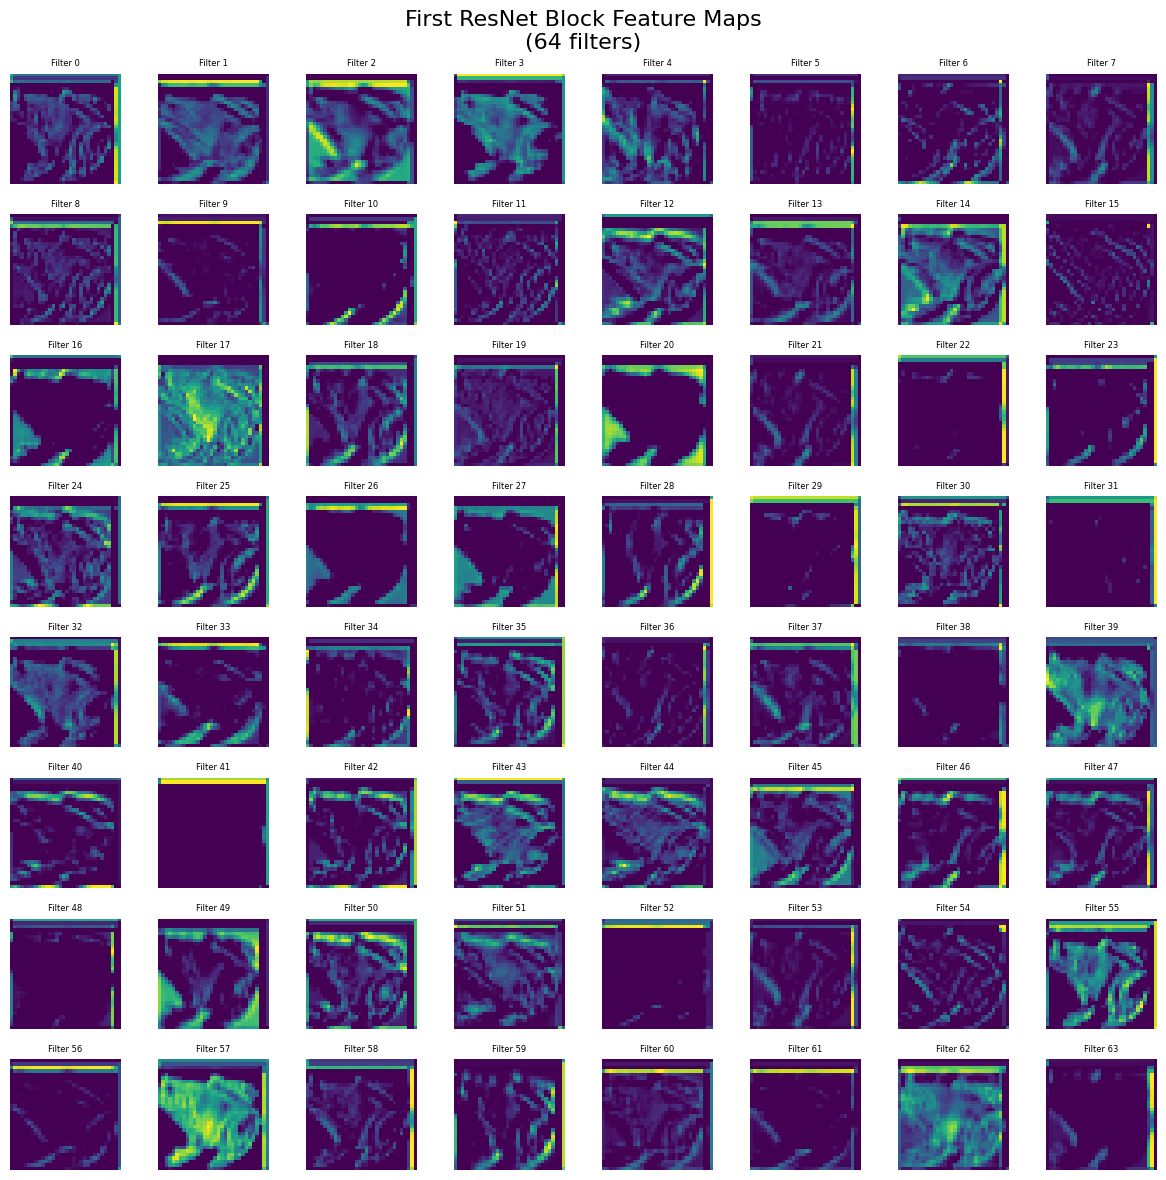

In [91]:
# Plot the feature maps
def plot_feature_maps(feature_tensor, title="Feature Maps"):
    """Plot feature maps from convolutional layers."""
    n_filters = feature_tensor.shape[1]
    grid_size = int(math.ceil(math.sqrt(n_filters)))

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
    fig.suptitle(f"{title}\n({n_filters} filters)", fontsize=16)

    for i in range(grid_size):
        for j in range(grid_size):
            idx = i * grid_size + j
            if idx < n_filters:
                feature_map = feature_tensor[0, idx].cpu().detach().numpy()
                feature_map = (feature_map - feature_map.min()) / (feature_map.max() - feature_map.min() + 1e-8)

                axes[i, j].imshow(feature_map, cmap='viridis')
                axes[i, j].set_title(f'Filter {idx}', fontsize=6)
                axes[i, j].axis('off')
            else:
                axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

# Plot the results
plot_feature_maps(intermediate_output, "First ResNet Block Feature Maps")

## CIFAR100

In this section, we aim to test the trained model on a different dataset. For this purpose, we will use the CIFAR100 dataset, which is similar to CIFAR10 but has different types and numbers of classes. In order for the model to perform well on the new dataset, we need to modify the last layer of the model. As you know from the previous section, the last layer of the model is a linear layer that maps the features to the number of classes. In this section, due to the increase in the number of classes, we plan to modify this layer and train the new linear layer with the new dataset. Note that all other layers and weights of the model will remain fixed and unchanged; only the last layer will be retrained.

### Dataset & Dataloader

Here, you should download and load the dataset with the desire transforms.

In [92]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                        std=[0.2675, 0.2565, 0.2761])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                        std=[0.2675, 0.2565, 0.2761])
])

# TODO: Load Train and Test Data
# Download and load CIFAR100 datasets
train_dataset = torchvision.datasets.CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)


batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

# Print dataset information
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Classes: {train_dataset.classes}")

100%|██████████| 169M/169M [00:03<00:00, 43.2MB/s]


Training samples: 50000
Test samples: 10000
Number of classes: 100
Classes: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tracto

In [134]:
classes = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee",
    "beetle", "bicycle", "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle", "chair", "chimpanzee",
    "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur", "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster",
    "house", "kangaroo", "keyboard", "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain", "mouse",
    "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine", "possum",
    "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor", "train",
    "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]
print(len(classes))

100


### Visualization

Visualize 1 random images from each class.

- **Hint**:  You can use `plt.subplots` for visualization

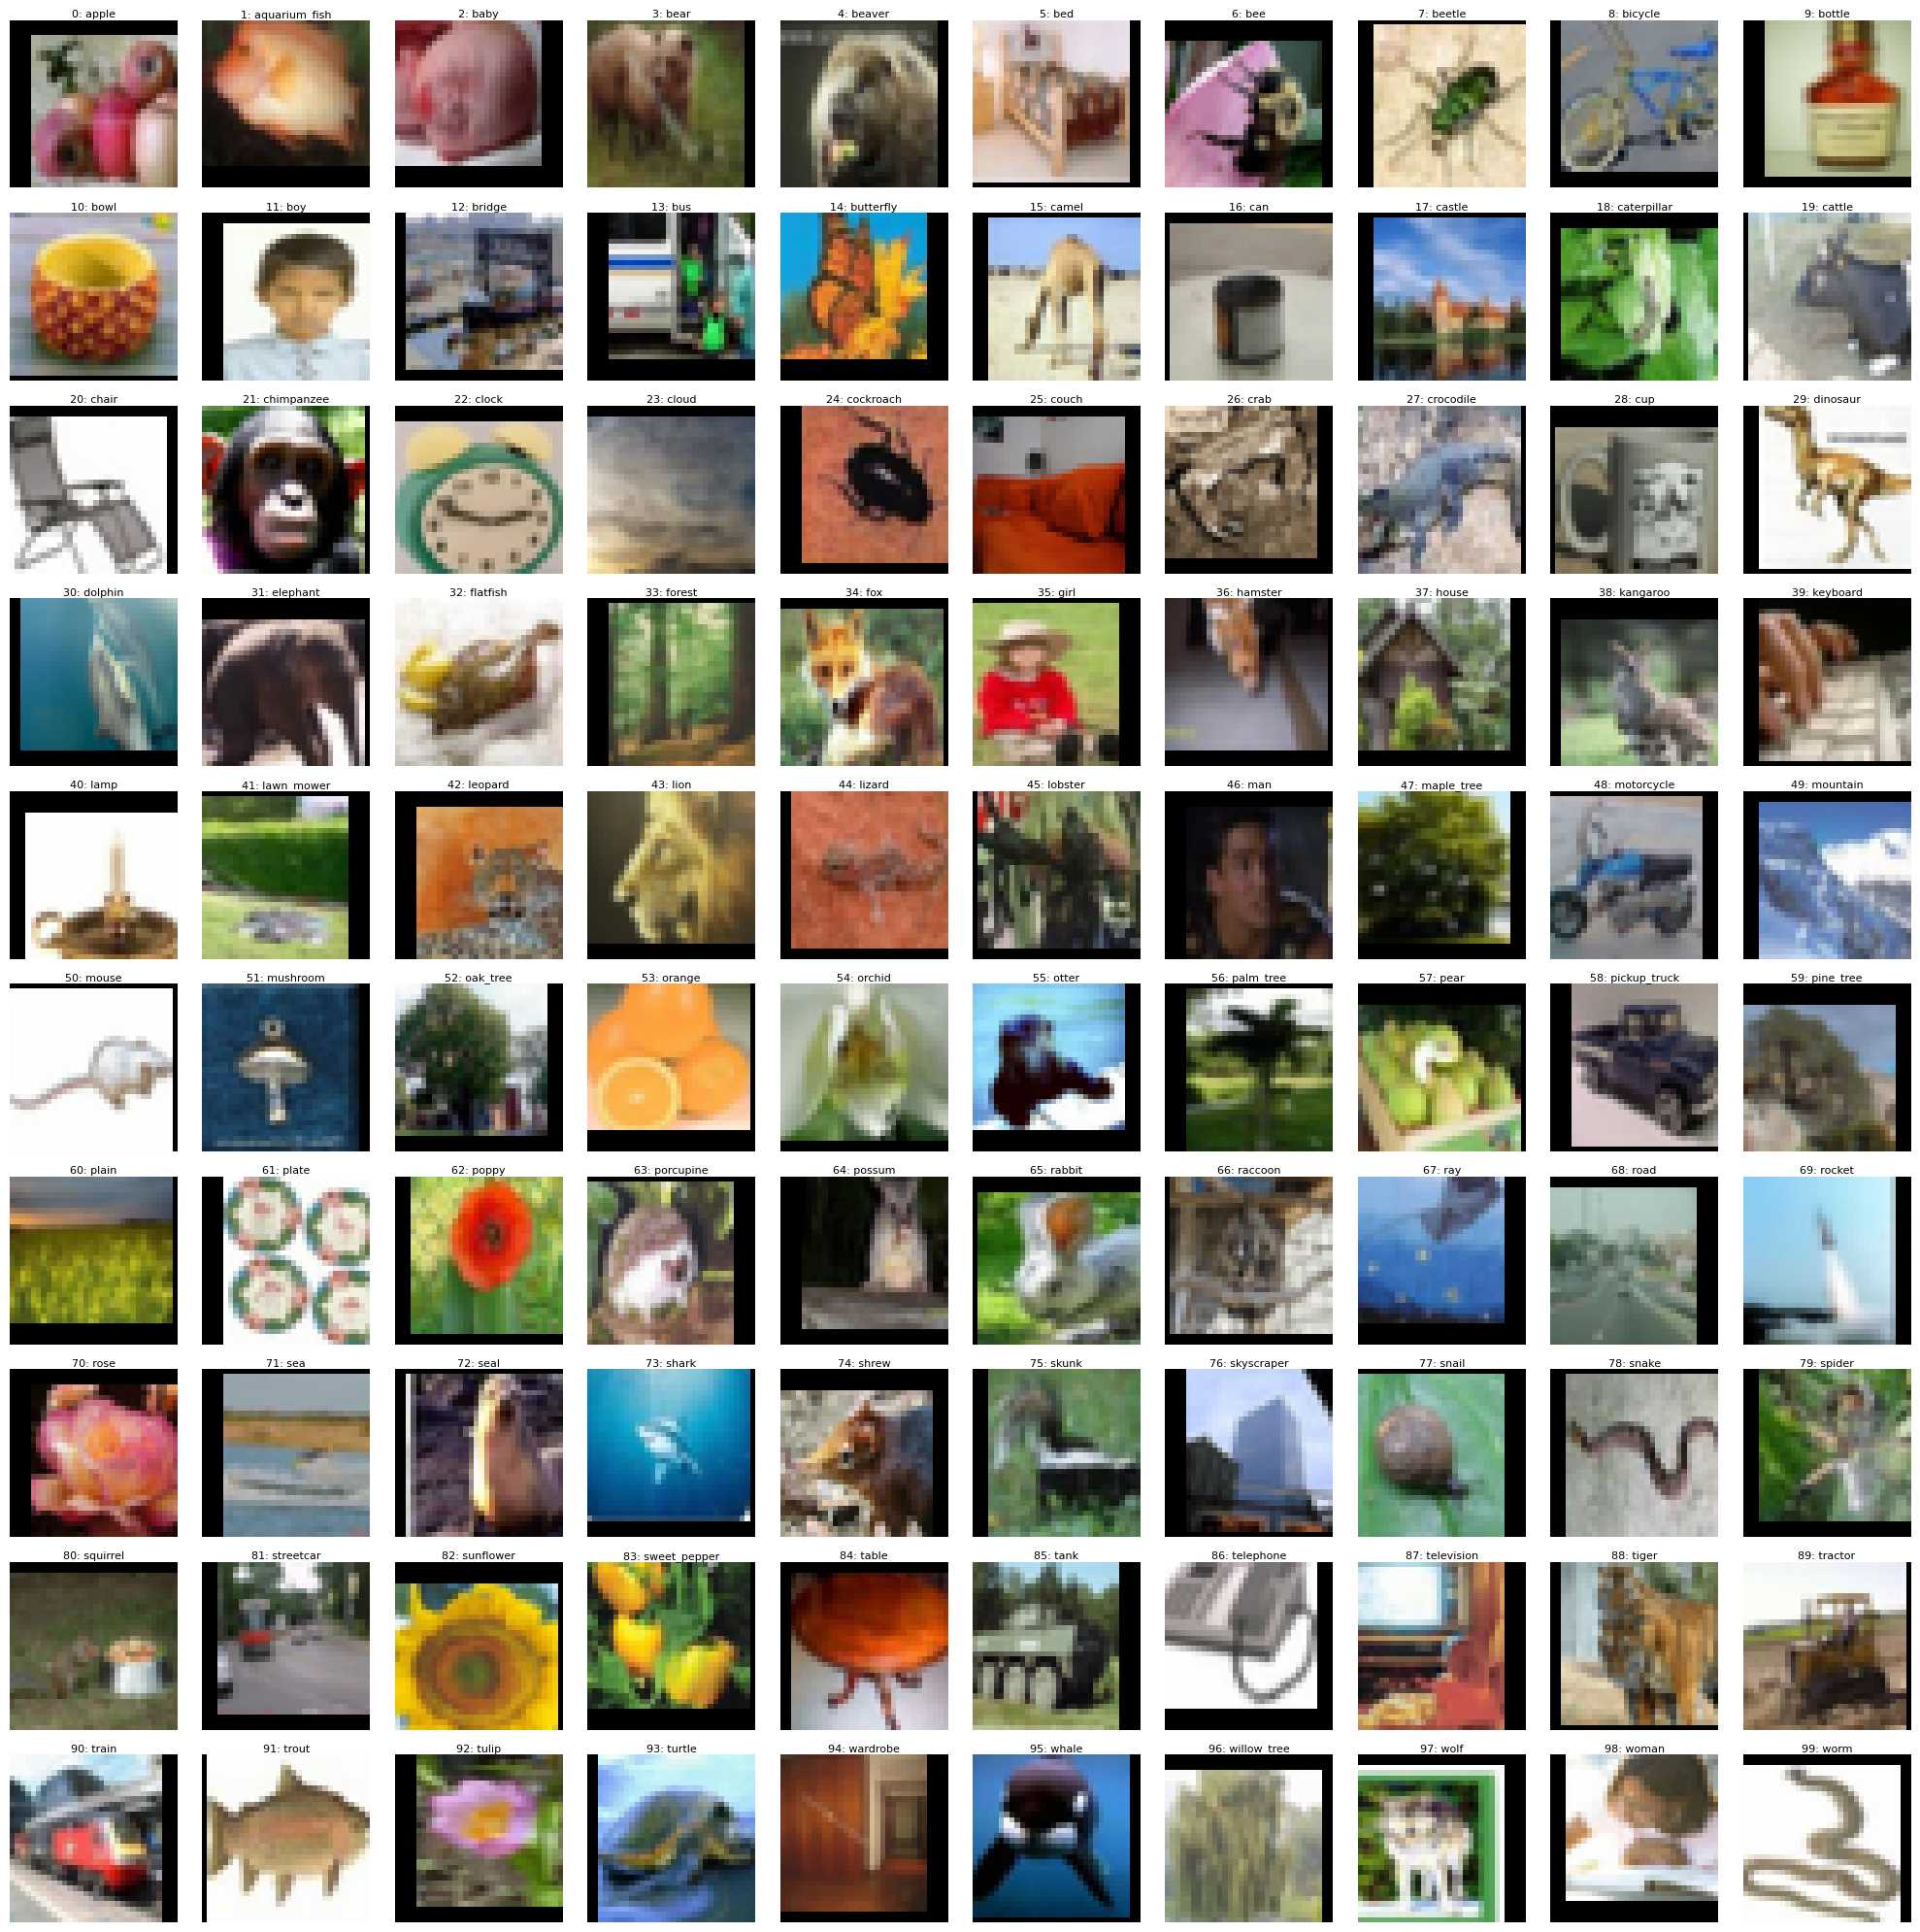

In [95]:
def find_one_image_per_class(dataset):
    """Find one random image from each class in the dataset"""
    class_indices = {}

    # Collect indices for each class
    for idx, (image, label) in enumerate(dataset):
        if label not in class_indices:
            class_indices[label] = []
        class_indices[label].append(idx)

    # Select one random index from each class
    selected_indices = {}
    for class_id, indices in class_indices.items():
        selected_indices[class_id] = np.random.choice(indices)

    return selected_indices

# Find one image per class from the training dataset
class_image_indices = find_one_image_per_class(train_dataset)

# TODO: Plot Images
# Create a large figure to display all 100 classes
fig, axes = plt.subplots(10, 10, figsize=(20, 20))

# CIFAR100 class names
class_names = train_dataset.classes

# Plot one image for each class
for class_id in range(100):
    # Get the random image index for this class
    idx = class_image_indices[class_id]

    # Get image and label
    image, label = train_dataset[idx]

    # Convert tensor image to numpy for plotting
    # CIFAR images are 3x32x32, need to convert to 32x32x3 for matplotlib
    image = image.numpy().transpose(1, 2, 0)

    # Denormalize the image for proper visualization
    mean = np.array([0.5071, 0.4867, 0.4408])
    std = np.array([0.2675, 0.2565, 0.2761])
    image = std * image + mean
    image = np.clip(image, 0, 1)

    # Get subplot position
    row = class_id // 10
    col = class_id % 10

    # Plot the image
    ax = axes[row, col]
    ax.imshow(image)
    ax.set_title(f'{class_id}: {class_names[class_id]}',
                fontsize=8, pad=2)
    ax.axis('off')

plt.tight_layout()
plt.show()




### Modify Model

Change the final linear layer of the model according to the new number of classes And freeze all other layers.
- Do not forgot to move model to `device`

In [135]:
import torch
import torch.nn as nn

# TODO: Load Pretrained Model
model_cifar100 = ResNetCustom(
    block=BasicBlock,
    layers=[3, 3, 3, 3],
    num_classes=10,
    feature_dim=512,
    zero_init_residual=True,
    dropout_rate=0.1,
    se_ratio=16,
    width_multiplier=1.0,
    stem_kernel=3
)

# Load your trained weights
model_cifar100.load_state_dict(torch.load('resnet_cifar10.pth'))

# TODO: Move Model to Device FIRST
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cifar100 = model_cifar100.to(device)

# TODO: Freeze All Layers
for param in model_cifar100.parameters():
    param.requires_grad = False

# TODO: Improved Last Layer
model_cifar100.fc = nn.Sequential(
    nn.Dropout(0.3),  # Regularization
    nn.Linear(512, 512),  # Larger hidden dimension
    nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.1),
    nn.Linear(256, 100)  # Final classification
).to(device)

# Unfreeze the new classifier
for param in model_cifar100.fc.parameters():
    param.requires_grad = True

# Verification
print("Model modified successfully!")
print(f"Final layer structure: {model_cifar100.fc}")

# Check trainable parameters
trainable_params = sum(p.numel() for p in model_cifar100.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_cifar100.parameters())
print(f"Trainable parameters: {trainable_params}/{total_params} ({trainable_params/total_params*100:.2f}%)")

# Enhanced training configuration
def get_enhanced_optimizer(model):
    # Different learning rates for different parts
    optimizer = torch.optim.AdamW([
        {'params': model.fc.parameters(), 'lr': 0.001, 'weight_decay': 1e-4},
    ])
    return optimizer

# Test the improved model
model_cifar100.eval()
with torch.no_grad():
    sample = torch.randn(1, 3, 32, 32).to(device)
    output = model_cifar100(sample)
    print(f"Output shape: {output.shape}")
    print(f"Model ready for training with enhanced classifier!")

Model modified successfully!
Final layer structure: Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=512, bias=True)
  (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU(inplace=True)
  (4): Dropout(p=0.2, inplace=False)
  (5): Linear(in_features=512, out_features=256, bias=True)
  (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): ReLU(inplace=True)
  (8): Dropout(p=0.1, inplace=False)
  (9): Linear(in_features=256, out_features=100, bias=True)
)
Trainable parameters: 421220/18259096 (2.31%)
Output shape: torch.Size([1, 100])
Model ready for training with enhanced classifier!


### Criterion & Optimizater

Define `criterion` and `optimizer` (Or `scheduler`)

In [136]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


scheduler = CosineAnnealingLR(optimizer, T_max=50)

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model_cifar100.parameters()),
    weight_decay=1e-4
)


### Train

Train the Model (Only Last Layer)


Epoch 1/20
--------------------------------------------------
Train Loss: 3.9868, Train Acc: 10.17%

Epoch 2/20
--------------------------------------------------
Train Loss: 3.7980, Train Acc: 13.66%

Epoch 3/20
--------------------------------------------------
Train Loss: 3.7543, Train Acc: 14.34%

Epoch 4/20
--------------------------------------------------
Train Loss: 3.7257, Train Acc: 15.17%

Epoch 5/20
--------------------------------------------------
Train Loss: 3.7036, Train Acc: 15.50%
Model saved at epoch 5

Epoch 6/20
--------------------------------------------------
Train Loss: 3.6918, Train Acc: 15.84%

Epoch 7/20
--------------------------------------------------
Train Loss: 3.6728, Train Acc: 16.22%

Epoch 8/20
--------------------------------------------------
Train Loss: 3.6691, Train Acc: 16.33%

Epoch 9/20
--------------------------------------------------
Train Loss: 3.6602, Train Acc: 16.48%

Epoch 10/20
--------------------------------------------------
Trai

Testing: 100%|██████████| 79/79 [00:03<00:00, 19.87it/s, Acc=24.17%]


Final Test Accuracy: 24.17%


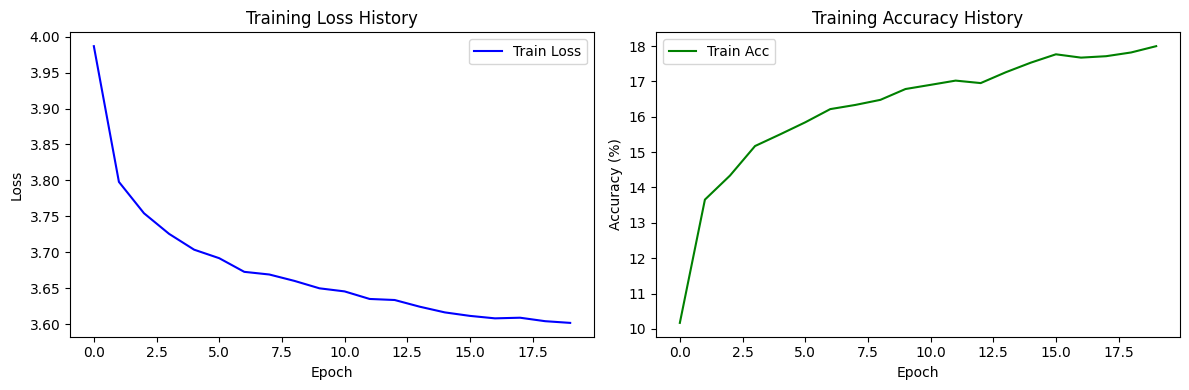


Training completed successfully!
Final test accuracy: 24.17%


In [137]:
# TODO: Training Function
def train_last_layer(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # pbar = tqdm(, desc='Training')
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        # Update progress bar


    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

# TODO: Training Loop
num_epochs = 20
train_losses = []
train_accuracies = []



for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 50)

    # Train
    train_loss, train_acc = train_last_layer(model_cifar100, train_loader, criterion, optimizer, device)

    # Update scheduler
    scheduler.step()

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')

    # Save model every 5 epochs
    if (epoch + 1) % 5 == 0:
        torch.save(model_cifar100.state_dict(), f'resnet_cifar100_epoch_{epoch+1}.pth')
        print(f'Model saved at epoch {epoch+1}')

# Save final model
torch.save(model_cifar100.state_dict(), 'resnet_cifar100_final.pth')
print(f'\nTraining completed! Final model saved.')

# TODO: Evaluate on test set
print("\nEvaluating on test set...")

def evaluate(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(test_loader, desc='Testing')
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            pbar.set_postfix({
                'Acc': f'{100.*correct/total:.2f}%'
            })

    test_acc = 100. * correct / total
    return test_acc

test_accuracy = evaluate(model_cifar100, test_loader, device)
print(f'Final Test Accuracy: {test_accuracy:.2f}%')

# TODO: Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss History')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Acc', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training Accuracy History')

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

print("\nTraining completed successfully!")
print(f"Final test accuracy: {test_accuracy:.2f}%")

accuracy of 24% is not bad for this task.becouse of the increase in classes we had. we see the model could capture good patterns from CIFAR10

### Visualize incorrectly predicted samples from testset

Visualize *10* random images from testset that are incorrectly predicted by the model

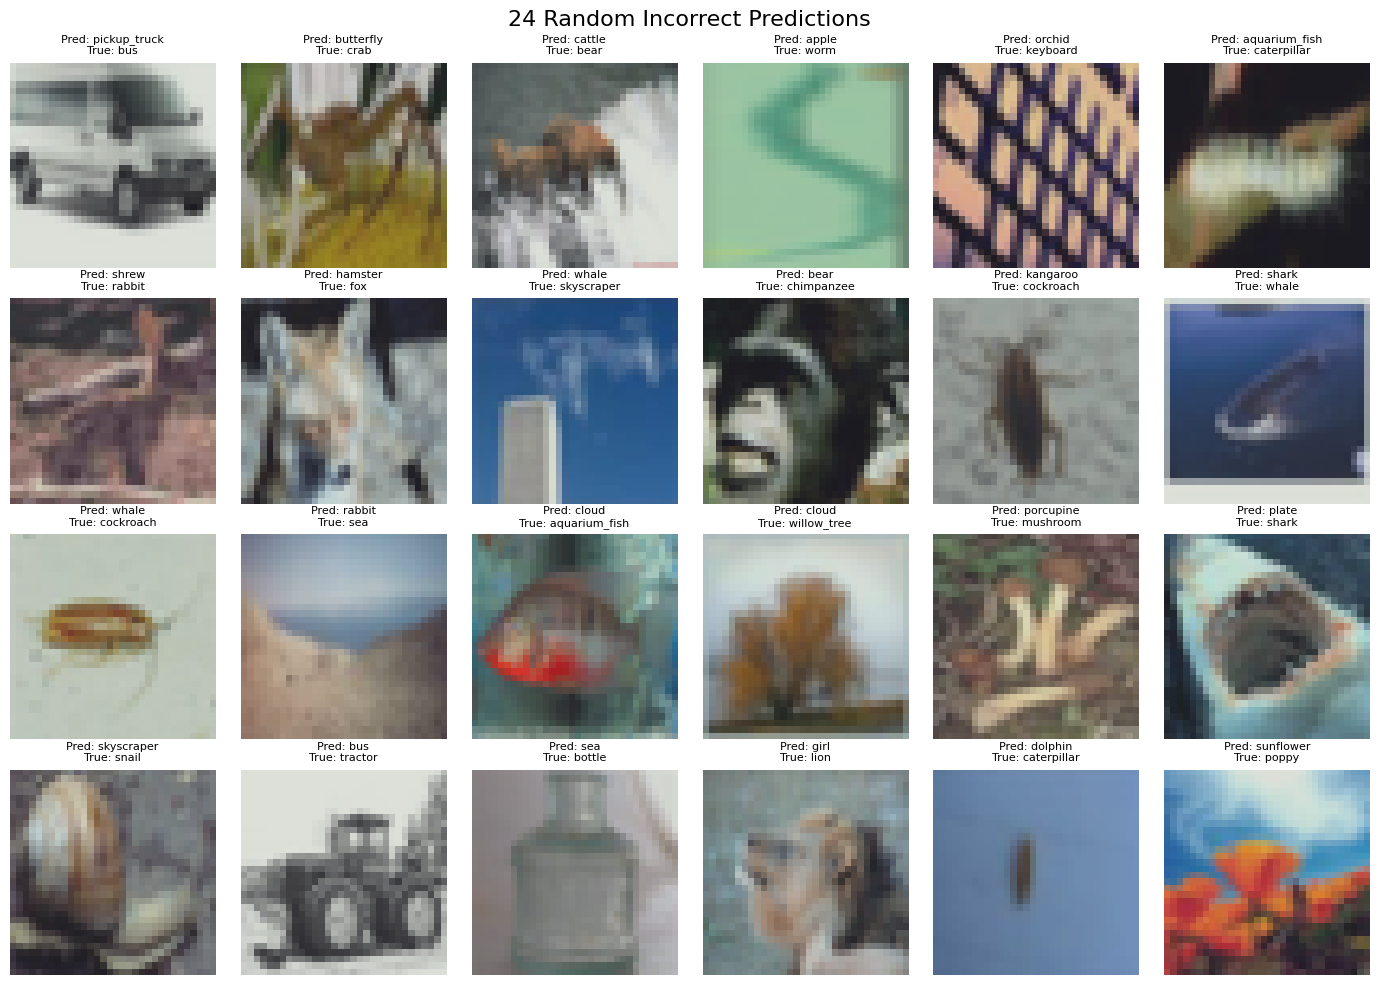

In [138]:
# TODO: Plot Samples with Wrong Predicted Classes
# Get misclassified samples
wrong_images, wrong_preds, wrong_labels = get_incorrect_samples(model_cifar100, test_loader, device)

# Pick 24 random wrong samples
indices = random.sample(range(len(wrong_images)), 24)

# Plot
fig, axes = plt.subplots(4, 6, figsize=(14, 10))
fig.suptitle("24 Random Incorrect Predictions", fontsize=16)

for ax, idx in zip(axes.flat, indices):
    img = imshow(wrong_images[idx].cpu())
    ax.imshow(img)
    ax.set_title(f"Pred: {classes[wrong_preds[idx]]}\nTrue: {classes[wrong_labels[idx]]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()
